In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
from torch_geometric.data import Data

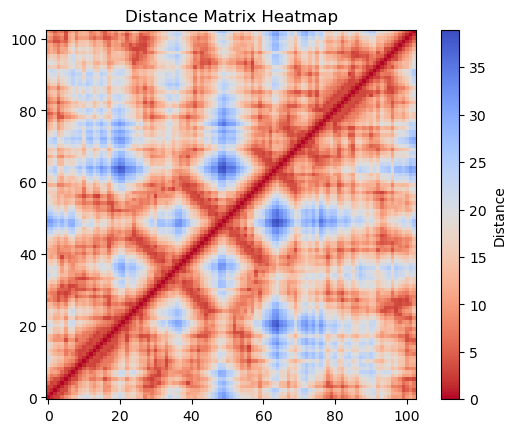

In [3]:
import sequenceHandler  
import importlib
importlib.reload(sequenceHandler)

from sequenceHandler import distance_map_PDB
pdb_file = "PDB/PF00017.pdb"
chain_id = "A"
output_map_file = "None"  

distance_map, residue = distance_map_PDB(pdb_file, chain_id, output_map_file)

import matplotlib.pyplot as plt

plt.figure()
plt.imshow(distance_map,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Distance")
plt.title("Distance Matrix Heatmap")
plt.show()

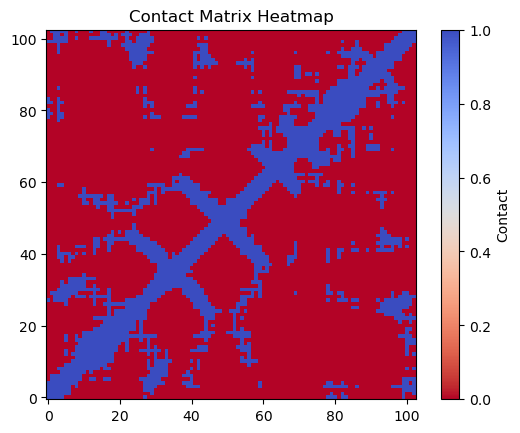

In [4]:
def contact_from_distance(distance_map, threshold=8.0):
    contact_map = (distance_map < threshold).astype(int)
    return contact_map  

contact_map = contact_from_distance(distance_map, threshold=8.0)

plt.figure()
plt.imshow(contact_map,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Contact")
plt.title("Contact Matrix Heatmap")
plt.show()

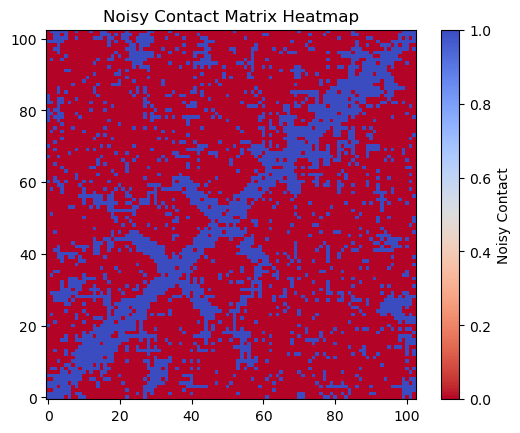

In [5]:
def create_noisy_contact_map(contact_map, noise_level=0.1):
    noisy_contact_map = contact_map.copy()
    num_elements = contact_map.size
    num_noisy_elements = int(noise_level * num_elements)
    
    indices = np.random.choice(num_elements, num_noisy_elements, replace=False)
    noisy_contact_map.flat[indices] = 1 - noisy_contact_map.flat[indices]
    
    return noisy_contact_map

noisy_contact_map= create_noisy_contact_map(contact_map, noise_level=0.1)

plt.figure()
plt.imshow(noisy_contact_map,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Noisy Contact")
plt.title("Noisy Contact Matrix Heatmap")
plt.show()  

In [6]:
def sinusoidal_positional_encoding(N, d_model):
    pe = torch.zeros(N, d_model)
    position = torch.arange(0, N, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # shape [N, d_model]

In [7]:
import numpy as np
import torch
from torch_geometric.data import Data

def build_graph_contact(noisy_contact_map, true_contact_map=None, sep_min=0):
    
    N = len(true_contact_map)

    src, dst = [], []
    edge_scores = []
    edge_labels = []
    edge_mask = []
    edge_pair_mask = []   # use only one direction for supervision/eval 

    
    for i in range(N):
        for j in range(N):
            if i == j:
                continue

            src.append(i)
            dst.append(j)

            edge_scores.append(noisy_contact_map[i, j])

            # devo tenere solo un contatto o tutte e due le coppie?
            pair_ok = (i < j)
            edge_pair_mask.append(pair_ok)

            # ignore short-range pairs ?
            long_range_ok = abs(i - j) >= sep_min

            if true_contact_map is not None:
                known = True
                label = float(true_contact_map[i,j])
            else:
                known = True
                label = 0.0

            edge_labels.append(label)
            #let's consider only the contact that are not inf and that are relevant
            edge_mask.append(known and long_range_ok)

    x = sinusoidal_positional_encoding(N, d_model=16)

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr = torch.tensor(edge_scores, dtype=torch.float).unsqueeze(-1)
    y = torch.tensor(edge_labels, dtype=torch.float).unsqueeze(-1)

    mask = torch.tensor(edge_mask, dtype=torch.bool)
    pair_mask = torch.tensor(edge_pair_mask, dtype=torch.bool)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,                 # binary contact labels
        edge_mask=mask,      # valid + long-range
        pair_mask=pair_mask, # only one direction per pair
        L=N
    )

In [8]:
import sequenceHandler  
import importlib
importlib.reload(sequenceHandler)
from sequenceHandler import distance_map_PDB

folder_path = "PDB"

all_data = []
for file in os.listdir(folder_path):
    pdb_path = os.path.join(folder_path, file)
    chain_id = "A"
    output_map_file = "None"  

    try:
        distance_map, __ = distance_map_PDB(pdb_path, chain_id, output_map_file)
        true_contact_map = contact_from_distance(distance_map, threshold=8.0)
        noisy_contact_map= create_noisy_contact_map(true_contact_map, noise_level=0.1)
        data = build_graph_contact(noisy_contact_map, true_contact_map)
        all_data.append(data)
    except:
        print(f"Some error occurred in the sequence {file}")

        
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(all_data, test_size=0.2, random_state=1)


train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
#train_loader = DataLoader([all_data[3]], batch_size=1)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

Some error occurred in the sequence PF07714.pdb
Some error occurred in the sequence PF00016.pdb
Some error occurred in the sequence PF00031.pdb
Some error occurred in the sequence PF00044.pdb
Some error occurred in the sequence PF00046.pdb
Some error occurred in the sequence PF00050.pdb
Some error occurred in the sequence PF00058.pdb
Some error occurred in the sequence PF00069.pdb
Some error occurred in the sequence PF00073.pdb
Some error occurred in the sequence PF00082.pdb
Some error occurred in the sequence PF00095.pdb
Some error occurred in the sequence PF00096.pdb
Some error occurred in the sequence PF00098.pdb
Some error occurred in the sequence PF00101.pdb
Some error occurred in the sequence PF00111.pdb
Some error occurred in the sequence PF00121.pdb
Some error occurred in the sequence PF00124.pdb
Some error occurred in the sequence PF00130.pdb
Some error occurred in the sequence PF00157.pdb
Some error occurred in the sequence PF00170.pdb
Some error occurred in the sequence PF00

In [9]:
import torch.nn as nn
from torch_geometric.nn import MessagePassing


# MessagePassing Module    
class EdgeMessagePassingLayer(MessagePassing):

    def __init__ (self, node_in_ch, edge_in_ch, node_out_ch, edge_out_ch, aggr='mean'):
        super(EdgeMessagePassingLayer, self).__init__(aggr=aggr, flow='source_to_target')  # <---- aggregation

        #print('Relu activation')

        # Edge MLP: [e_ij, x_i, x_j] -> e'_ij
        self.lin_phi_e = nn.Sequential(
            nn.Linear(edge_in_ch + 2 * node_in_ch, edge_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(edge_out_ch, edge_out_ch)
        )

        # Node MLP: [x_i(old), agg([x_i, x_j, e'_ij] sugli edge incidenti a i)] -> x_i(new)
        self.lin_phi_x = nn.Sequential(
            nn.Linear(node_in_ch + (2 * node_in_ch + edge_out_ch),  node_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(node_out_ch, node_out_ch)
        )
    
    def forward(self, x, edge_index, edge_attr):
        assert edge_attr is not None, 'Questa GNN runna solo con edge_attr!'
        
        # 1. Update edges
        edge_attr = self.edge_updater(edge_index, x=x, edge_attr=edge_attr)
        # 2. Update nodes
        x_out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        return x_out, edge_attr

    # -- EDGES --  <--- self.edge_updater
    def edge_update(self, x_i, x_j, edge_attr):
        edge_attr_out = self.lin_phi_e( torch.cat([edge_attr, x_i, x_j], dim=-1) )
        return edge_attr_out
        
    # -- NODES --   <--- self.propagate
    def message(self, x_i, x_j, edge_attr):
        message = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return message

    # ... aggregate con mean o add nell'init ...

    def update(self, aggr_out, x):
        aggr = torch.cat([x, aggr_out], dim=-1)
        x_out = self.lin_phi_x(aggr)
        return x_out

In [10]:
from torch_geometric.nn import LayerNorm
import torch.nn.functional as F

class EdgeGNN(nn.Module):
    def __init__(self, node_in_ch = 8, edge_in_ch = 8, node_out_ch = 1, multipl_mid_layers = 2, edge_out_ch = 2, GNN_layers=4, node_norms =True, edge_norms=True, gating=True):
        super(EdgeGNN, self).__init__() 

        self.convs = nn.ModuleList()
        self.node_norms = nn.ModuleList() if node_norms else None
        self.edge_norms = nn.ModuleList() if edge_norms else None
        self.gating = nn.ModuleList() if gating else None

        # First layer
        if self.node_norms is not None:
            self.node_norms.append(LayerNorm(node_in_ch))
        if self.edge_norms is not None:
            self.edge_norms.append(LayerNorm(edge_in_ch))
        self.convs.append(EdgeMessagePassingLayer(
            node_in_ch = node_in_ch,
            edge_in_ch = edge_in_ch,
            node_out_ch = node_in_ch * multipl_mid_layers,
            edge_out_ch = edge_in_ch * multipl_mid_layers
        ))
        if self.gating is not None:
            self.gating.append(nn.Sequential(
            nn.Linear(edge_in_ch * multipl_mid_layers, edge_in_ch * multipl_mid_layers),
            nn.Sigmoid()
            ))

        # Layer Intermedi
        for _ in range(GNN_layers - 2):
            if self.node_norms is not None:
                self.node_norms.append(LayerNorm(node_in_ch * multipl_mid_layers))
            if self.edge_norms is not None:
                self.edge_norms.append(LayerNorm(edge_in_ch * multipl_mid_layers))

            self.convs.append(EdgeMessagePassingLayer(
                node_in_ch=node_in_ch * multipl_mid_layers,
                edge_in_ch=edge_in_ch * multipl_mid_layers,
                node_out_ch=node_in_ch * multipl_mid_layers,
                edge_out_ch=edge_in_ch * multipl_mid_layers
            ))
            
            if self.gating is not None:
                self.gating.append(nn.Sequential(
                nn.Linear(edge_in_ch * multipl_mid_layers, edge_in_ch * multipl_mid_layers),
                nn.Sigmoid()
                ))

        # Final Intermediate layer
        self.convs.append(EdgeMessagePassingLayer(
            node_in_ch=node_in_ch * multipl_mid_layers,
            edge_in_ch=edge_in_ch * multipl_mid_layers,
            node_out_ch=node_out_ch,
            edge_out_ch=edge_out_ch
        ))

    def forward(self, graph):
        x, edge_index, edge_attr, batch = graph.x, graph.edge_index, graph.edge_attr, graph.batch

        edge_batch = batch[edge_index[0]]  # batch degli edge = batch del nodo sorgente

        for i, (node_norm, edge_norm, conv) in enumerate(zip(self.node_norms, self.edge_norms, self.convs[:-1])):
            x_in = x
            e_in = edge_attr
            x = node_norm(x, batch) if node_norm is not None else x
            edge_attr = edge_norm(edge_attr, edge_batch) if edge_norm is not None else edge_attr

            x, edge_attr = conv(x, edge_index, edge_attr)

            if x_in.shape == x.shape:
                x = x + x_in
            if e_in.shape == edge_attr.shape:
                gate = self.gating[i](edge_attr) if self.gating is not None else 1.0
                edge_attr = edge_attr * gate  # edge gating
                edge_attr = edge_attr + e_in

            x = F.leaky_relu(x, negative_slope=0.2)
            edge_attr = F.leaky_relu(edge_attr, negative_slope=0.2)

            #x = self.dropout(x)
            #edge_attr = self.dropout(edge_attr)

        # Final projection to output space
        x, edge_attr = self.convs[-1](x, edge_index, edge_attr)

        return x, edge_attr

In [11]:
def compute_pos_weight(loader, device):
    total_pos = 0
    total_neg = 0

    for batch in loader:
        batch = batch.to(device)

        y = batch.y.squeeze(-1)
        mask = batch.edge_mask #& batch.pair_mask  

        y = y[mask]

        total_pos += (y == 1).sum().item()
        total_neg += (y == 0).sum().item()

    pos_weight = total_neg / max(total_pos, 1)
    return torch.tensor(pos_weight, dtype=torch.float, device=device)

In [12]:
def average_loss(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_edges = 0
    total_batches= 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            _, pred_logits = model(batch)
            pred_logits = pred_logits.squeeze(-1)
            true_contacts = batch.y.squeeze(-1)

            mask = batch.edge_mask #& batch.pair_mask

            loss = loss_fn(pred_logits[mask], true_contacts[mask])

            n_edges = mask.sum().item()
            total_loss += loss.item() * n_edges
            total_edges += n_edges
            total_batches += 1

    return total_loss / max(total_edges, 1)


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = EdgeGNN(node_in_ch=16, edge_in_ch=1, edge_out_ch=1, GNN_layers=6).to(device)

pos_weight = compute_pos_weight(train_loader, device)
print("pos_weight:", pos_weight.item())
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight,reduction='mean')

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

train_losses = []
val_losses = []

for epoch in range(200):

    model.train()

    for batch in train_loader:

        batch = batch.to(device)
        optimizer.zero_grad()

        _, pred_logits = model(batch)

        pred_logits = pred_logits.squeeze(-1)
        true_contacts = batch.y.squeeze(-1)

        mask = batch.edge_mask #& batch.pair_mask

        loss = loss_fn(pred_logits[mask], true_contacts[mask])

        loss.backward()
        optimizer.step()

    train_loss = average_loss(model, train_loader, loss_fn, device)
    val_loss = average_loss(model, test_loader, loss_fn, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

pos_weight: 15.704546928405762
Epoch 0: Train Loss=1.2018, Val Loss=1.2219
Epoch 1: Train Loss=0.6162, Val Loss=0.6229
Epoch 2: Train Loss=0.5822, Val Loss=0.5904
Epoch 3: Train Loss=0.5480, Val Loss=0.5582
Epoch 4: Train Loss=0.5178, Val Loss=0.5288
Epoch 5: Train Loss=0.4993, Val Loss=0.5114
Epoch 6: Train Loss=0.4871, Val Loss=0.4978
Epoch 7: Train Loss=0.5827, Val Loss=0.5975
Epoch 8: Train Loss=0.4851, Val Loss=0.4949
Epoch 9: Train Loss=0.4763, Val Loss=0.4863
Epoch 10: Train Loss=0.4718, Val Loss=0.4826
Epoch 11: Train Loss=0.4791, Val Loss=0.4890
Epoch 12: Train Loss=0.4699, Val Loss=0.4776
Epoch 13: Train Loss=0.4682, Val Loss=0.4754
Epoch 14: Train Loss=0.4655, Val Loss=0.4738
Epoch 15: Train Loss=0.4598, Val Loss=0.4686
Epoch 16: Train Loss=0.4708, Val Loss=0.4802
Epoch 17: Train Loss=0.4586, Val Loss=0.4688
Epoch 18: Train Loss=0.4562, Val Loss=0.4660
Epoch 19: Train Loss=0.4503, Val Loss=0.4602
Epoch 20: Train Loss=0.4566, Val Loss=0.4667
Epoch 21: Train Loss=0.4630, Val L

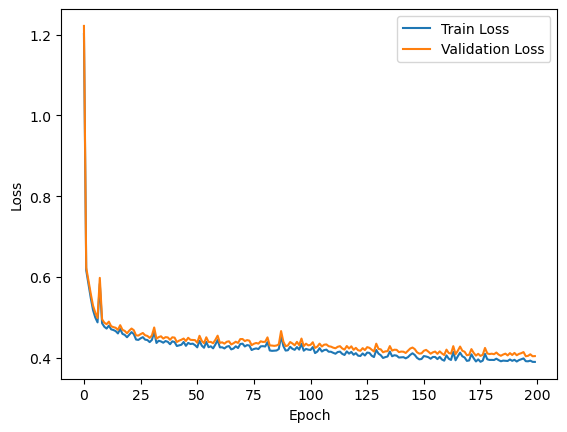

In [14]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Precision of the GNN: 0.4289914326914921
Recall of the GNN: 0.9208261868606866
F1 of the GNN: 0.5853035838904892
AUPRC of the GNN: 0.7917004688731957
Validation ROC AUC GNN: 0.9708404490106332


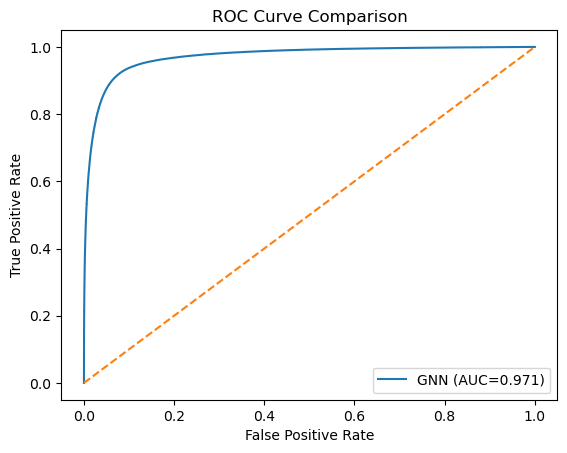

PR AUC GNN: 0.7917002662746683


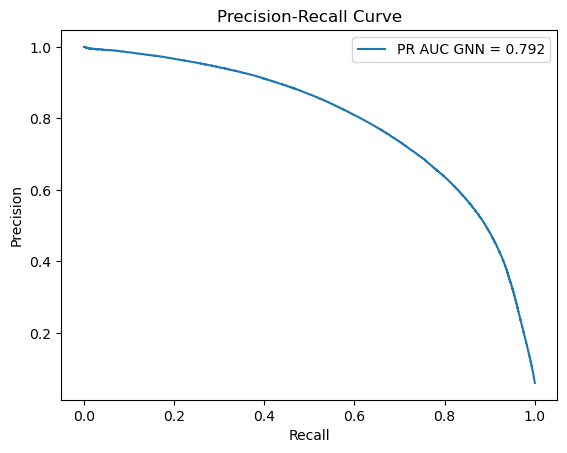

In [15]:
from sklearn.metrics import auc, precision_score, recall_score, f1_score, average_precision_score, roc_curve

model.eval()

all_probs = []
all_true = []

for batch in test_loader:
    batch = batch.to(device)

    with torch.no_grad():
        _, pred_logits = model(batch)
        probs = torch.sigmoid(pred_logits.squeeze(-1))

    true_contacts = batch.y.squeeze(-1)
    mask = batch.edge_mask & batch.pair_mask
  


    all_probs.append(probs[mask].cpu())
    all_true.append(true_contacts[mask].cpu())

all_probs = torch.cat(all_probs)
all_true = torch.cat(all_true)


threshold=0.5

pred_contacts = (all_probs >= threshold).int().numpy()
true_contacts = all_true.int().numpy()

precision = precision_score(true_contacts, pred_contacts, zero_division=0)
recall = recall_score(true_contacts, pred_contacts, zero_division=0)
f1 = f1_score(true_contacts, pred_contacts, zero_division=0)
auprc = average_precision_score(true_contacts, all_probs.numpy())

print(f"Precision of the GNN: {np.mean(precision)}")
print(f"Recall of the GNN: {np.mean(recall)}")
print(f"F1 of the GNN: {np.mean(f1)}")
print(f"AUPRC of the GNN: {np.mean(auprc)}")



# compute ROC
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

print("Validation ROC AUC GNN:", roc_auc)


plt.figure()

plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

#compute PR
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(all_true, all_probs)
pr_auc = auc(recall, precision)


print("PR AUC GNN:", pr_auc)


plt.figure()
plt.plot(recall, precision, label=f"PR AUC GNN = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [17]:

def topk_L_precision(model, loader, device, ratio=1.0):
    model.eval()
    per_graph_precisions = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            _, logits = model(batch)

            probs = torch.sigmoid(logits.squeeze(-1))
            true_contacts = batch.y.squeeze(-1)

            valid_mask = batch.edge_mask & batch.pair_mask

            # graph id for each edge
            edge_graph_id = batch.batch[batch.edge_index[0]]

            num_graphs = batch.num_graphs

            for g in range(num_graphs):
                graph_mask = valid_mask & (edge_graph_id == g)

                probs_g = probs[graph_mask]
                true_g = true_contacts[graph_mask]

                if probs_g.numel() == 0:
                    continue

                # length of the protein
                L = int(batch.L[g]) if torch.is_tensor(batch.L) else int(batch.L)

                k = max(1, int(L * ratio))
                k = min(k, probs_g.numel())

                top_idx = torch.topk(probs_g, k=k).indices
                #knumber of true contacts in top-k​/k
                precision_g = (true_g[top_idx] > 0.5).float().mean().item()

                per_graph_precisions.append(precision_g)

    return float(np.mean(per_graph_precisions)), per_graph_precisions

print("Top-k*L precision:", topk_L_precision(model, test_loader, device, ratio=7)[0])

Top-k*L precision: 0.8769014647533727


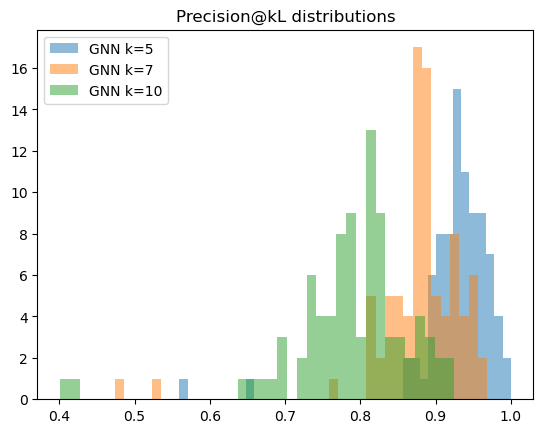

In [18]:
k_values = [5,7,10]
results = {k: [] for k in k_values}
for k in k_values:
    vals= topk_L_precision(model, test_loader, device, ratio=k)[1]
    results[k].extend(vals)

for k in k_values:
    plt.hist(results[k], bins=40, alpha=0.5, label=f"GNN k={k}")


plt.legend()
plt.title("Precision@kL distributions")
plt.show()

In [20]:
k=5
precision= topk_L_precision(model, test_loader, device, ratio=k)[1]
print(precision)
print(min(precision))
print(precision.index(min(precision)))

[0.9137254953384399, 0.8578947186470032, 0.9233115911483765, 0.9266666769981384, 0.9645161032676697, 0.9445887804031372, 0.9083333611488342, 0.9422924518585205, 0.9764705300331116, 0.9928571581840515, 0.9556451439857483, 0.9733333587646484, 0.9002028703689575, 0.9305936098098755, 0.916216254234314, 0.9659574031829834, 0.9245790839195251, 0.6510538458824158, 0.9682819843292236, 0.8967347145080566, 0.9161290526390076, 0.8939024209976196, 0.9428571462631226, 0.945794403553009, 0.9474178552627563, 0.9090909361839294, 0.9586206674575806, 0.9125257134437561, 0.9248780608177185, 0.9273684024810791, 0.9228346347808838, 0.9217759370803833, 0.9500000476837158, 0.9372549653053284, 0.9393939971923828, 0.9058139324188232, 0.931932806968689, 0.8967742323875427, 0.9666666984558105, 0.5596330165863037, 0.9647058248519897, 0.9399999976158142, 0.9726027846336365, 0.9333333373069763, 0.8764940500259399, 0.9075269103050232, 0.9465649127960205, 0.9886792898178101, 0.9710691571235657, 0.9288888573646545, 0.

In [21]:
def graph_to_matrix(data, values):
    num_nodes = data.x.shape[0]
    mat = torch.zeros((num_nodes, num_nodes))

    edge_index = data.edge_index
    mat[edge_index[0], edge_index[1]] = values.squeeze()

    return mat

Data(x=[218, 16], edge_index=[2, 47306], edge_attr=[47306, 1], y=[47306, 1], edge_mask=[47306], pair_mask=[47306], L=218)


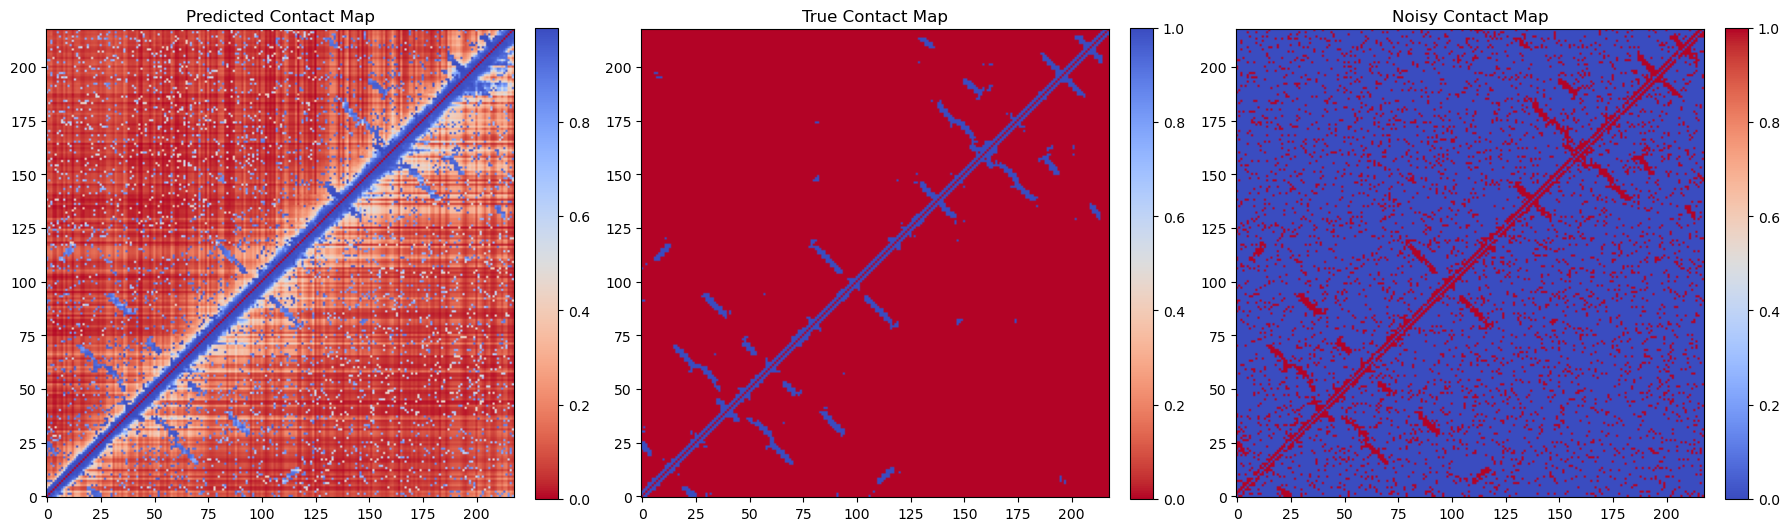

In [32]:
pos=39
#worst case

i=0
with torch.no_grad():
    for batch in test_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_logits = model(batch)
        i+=1

batch=test_data[pos]
print(batch)

mask = batch.edge_mask & batch.pair_mask

scores = torch.sigmoid(pred_logits.squeeze(-1))
# threshold=0.5
# scores= (scores>= threshold).float()
pred_contact_map = graph_to_matrix(batch, scores.cpu())
true_contact_map = graph_to_matrix(batch, batch.y.cpu())
noisy_contact_map_map = graph_to_matrix(batch, batch.edge_attr.cpu())



fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_contact_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---
im1 = axes[1].imshow(true_contact_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original Noisy Contact Map ---
im2 = axes[2].imshow(noisy_contact_map_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Noisy Contact Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()